# 🖥️ Traffic Sign Classifier — Notebook 3: Giao diện GUI (Tkinter)

---

**Mục tiêu:** Giải thích và demo giao diện đồ họa Tkinter cho phép người dùng **tải ảnh từ file** và nhận diện biển báo giao thông.

**Tính năng GUI:**
- 📂 Mở ảnh từ máy tính (PNG, JPG, BMP, PPM)
- 🔍 Nhận diện và hiển thị **Top 3 dự đoán** với thanh confidence
- ✅/⚠️/❌ Màu sắc theo độ tự tin (≥70% / ≥40% / <40%)
- ❓ Phát hiện ảnh không phải biển báo (confidence < 30%)
- 🗑️ Reset để thử ảnh khác

---
> ⚠️ **Yêu cầu:** File `traffic_classifier.h5` và `labels.json` phải cùng thư mục.

## 📦 Bước 0 — Import và kiểm tra

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

# Kiểm tra file cần thiết
required_files = {
    "traffic_classifier.h5" : "Model CNN đã huấn luyện",
    "labels.json"           : "Bản đồ class → tên biển báo",
}

print("🔍 Kiểm tra file cần thiết:")
all_ok = True
for fname, desc in required_files.items():
    exists = os.path.exists(fname)
    status = "✅" if exists else "❌"
    size   = f"({os.path.getsize(fname)/1024:.0f} KB)" if exists else ""
    print(f"   {status} {fname}  {size}  — {desc}")
    if not exists:
        all_ok = False

if not all_ok:
    print("\n⚠️  Chạy notebook 01_Train.ipynb trước để tạo các file trên!")
else:
    print("\n✅ Sẵn sàng!")

🔍 Kiểm tra file cần thiết:
   ✅ traffic_classifier.h5  (19119 KB)  — Model CNN đã huấn luyện
   ✅ labels.json  (2 KB)  — Bản đồ class → tên biển báo

✅ Sẵn sàng!


## 📖 Bước 1 — Load labels.json

File `labels.json` ánh xạ class ID → tên tiếng Việt của biển báo.

In [2]:
def load_labels(path="labels.json"):
    """
    Load file labels.json và trả về dict {int: str}.
    Trả về None nếu file không tồn tại.
    """
    if not os.path.exists(path):
        return None
    with open(path, "r", encoding="utf-8") as f:
        raw = json.load(f)                  # {'0': 'tên', '1': 'tên', ...}
    return {int(k): v for k, v in raw.items()}  # Chuyển key sang int


class_names = load_labels()

if class_names:
    print(f"✅ Đã load {len(class_names)} nhãn")
    print("\nMột số nhãn mẫu:")
    for k in [0, 9, 14, 17, 35, 40]:
        print(f"   Class {k:2d} → {class_names[k]}")
else:
    print("❌ Không tìm thấy labels.json")

✅ Đã load 43 nhãn

Một số nhãn mẫu:
   Class  0 → Giới hạn tốc độ 20 km/h
   Class  9 → Cấm vượt
   Class 14 → Dừng lại
   Class 17 → Cấm vào
   Class 35 → Chỉ được đi thẳng
   Class 40 → Vòng xuyến


### 📊 Visualize toàn bộ 43 nhãn

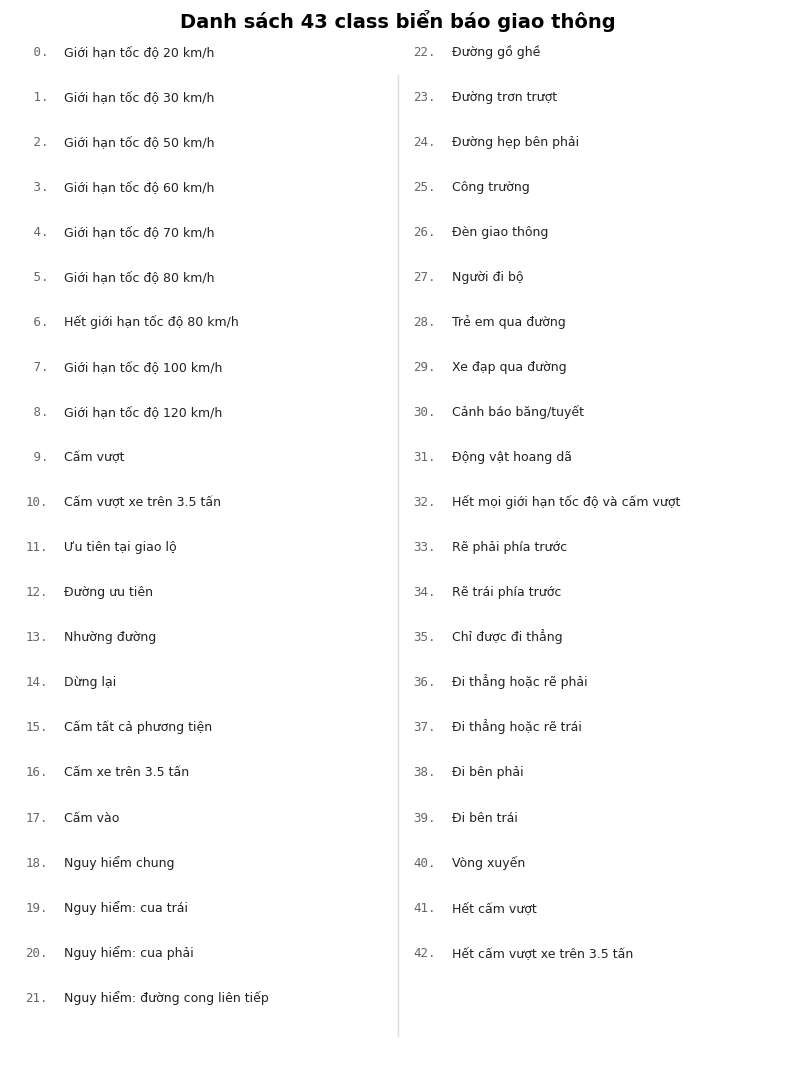

💾 Đã lưu: label_list.png


In [3]:
if class_names:
    fig, ax = plt.subplots(figsize=(10, 13))
    ax.axis('off')
    ax.set_title('Danh sách 43 class biển báo giao thông', fontsize=14,
                 fontweight='bold', pad=20)

    col1 = [(k, v) for k, v in class_names.items() if k < 22]
    col2 = [(k, v) for k, v in class_names.items() if k >= 22]

    for i, (k, v) in enumerate(col1):
        y = 1.0 - i * 0.045
        ax.text(0.02, y, f"{k:2d}.", transform=ax.transAxes,
                fontsize=9, color='#666', family='monospace')
        ax.text(0.07, y, v, transform=ax.transAxes, fontsize=9, color='#222')

    for i, (k, v) in enumerate(col2):
        y = 1.0 - i * 0.045
        ax.text(0.52, y, f"{k:2d}.", transform=ax.transAxes,
                fontsize=9, color='#666', family='monospace')
        ax.text(0.57, y, v, transform=ax.transAxes, fontsize=9, color='#222')

    ax.plot([0.5, 0.5], [0.02, 0.98], color='#DDD', linewidth=1, transform=ax.transAxes)

    plt.savefig('label_list.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("💾 Đã lưu: label_list.png")

## 🧠 Bước 2 — Load model

In [4]:
from tensorflow.keras.models import load_model as keras_load_model

def load_model_once(path="traffic_classifier.h5"):
    """
    Load Keras model từ file .h5.
    Trả về (model, None) nếu thành công.
    Trả về (None, error_string) nếu thất bại.
    """
    try:
        if not os.path.exists(path):
            return None, f"Không tìm thấy: {path}"
        return keras_load_model(path), None
    except Exception as e:
        return None, str(e)


print("⏳ Đang tải model...")
model, err = load_model_once()

if model:
    print(f"✅ Model sẵn sàng!")
    print(f"   Input  : {model.input_shape}")
    print(f"   Output : {model.output_shape}  (43 class)")
else:
    print(f"❌ Lỗi: {err}")

c:\Users\Lactv\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.0) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


⏳ Đang tải model...


✅ Model sẵn sàng!
   Input  : (None, 30, 30, 3)
   Output : (None, 43)  (43 class)


## 🔮 Bước 3 — Hàm predict_top3

Trả về **3 class có xác suất cao nhất** cùng với confidence tương ứng.

In [5]:
def predict_top3(model, pil_image):
    """
    Nhận PIL Image bất kỳ, trả về top 3 dự đoán.

    Tham số:
        model     : Keras model
        pil_image : PIL.Image (bất kỳ mode, bất kỳ kích thước)

    Trả về:
        List of (class_id: int, confidence: float) — 3 phần tử, giảm dần
    """
    # Đảm bảo RGB và resize về 30×30
    img = pil_image.convert("RGB").resize((30, 30))

    # Chuyển sang numpy, normalize, thêm batch dim
    arr = np.expand_dims(np.array(img, dtype=np.float32) / 255.0, axis=0)

    # Predict → softmax output shape (43,)
    preds = model.predict(arr, verbose=0)[0]

    # Lấy top 3 index theo thứ tự giảm dần
    top3 = np.argsort(preds)[::-1][:3]

    return [(int(i), float(preds[i])) for i in top3]


print("✅ Hàm predict_top3 đã định nghĩa")

✅ Hàm predict_top3 đã định nghĩa


### 🧪 Test predict_top3 với ảnh mẫu

In [6]:
# Test với ảnh ngẫu nhiên
dummy_img = Image.fromarray(
    np.random.randint(0, 255, (100, 100, 3), dtype=np.uint8)
)

if model:
    results = predict_top3(model, dummy_img)
    print("🧪 Kết quả test với ảnh ngẫu nhiên 100×100:")
    medals = ['🥇', '🥈', '🥉']
    for rank, (cid, conf) in enumerate(results):
        name = class_names.get(cid, f'Class {cid}') if class_names else f'Class {cid}'
        print(f"   {medals[rank]} #{rank+1}: [{cid:2d}] {name:<35}  {conf*100:.2f}%")

    total = sum(p for _, p in results)
    print(f"\n   (3 class trên chiếm {total*100:.1f}% tổng xác suất)")

🧪 Kết quả test với ảnh ngẫu nhiên 100×100:
   🥇 #1: [ 3] Giới hạn tốc độ 60 km/h              14.85%
   🥈 #2: [ 1] Giới hạn tốc độ 30 km/h              9.65%
   🥉 #3: [ 5] Giới hạn tốc độ 80 km/h              8.12%

   (3 class trên chiếm 32.6% tổng xác suất)


## 🎨 Bước 4 — Phân tích logic hiển thị kết quả

GUI sử dụng 2 ngưỡng để phân loại hiển thị:

| Confidence | Biểu tượng | Màu | Ý nghĩa |
|:---:|:---:|:---:|---|
| < 30% | ❓ | Đỏ | Không nhận ra — không phải biển báo |
| 30% – 69% | ⚠️ | Vàng | Nhận ra nhưng chưa chắc |
| ≥ 70% | ✅ | Xanh | Tin cậy cao |

C:\Users\Lactv\AppData\Local\Temp\ipykernel_22972\4092326532.py:49: UserWarning: Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from current font.
  plt.tight_layout()
C:\Users\Lactv\AppData\Local\Temp\ipykernel_22972\4092326532.py:49: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()
C:\Users\Lactv\AppData\Local\Temp\ipykernel_22972\4092326532.py:49: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
C:\Users\Lactv\AppData\Local\Temp\ipykernel_22972\4092326532.py:50: UserWarning: Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from current font.
  plt.savefig('confidence_zones.png', dpi=150, bbox_inches='tight')
C:\Users\Lactv\AppData\Local\Temp\ipykernel_22972\4092326532.py:50: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.savefig('confidence_zones.png', dpi=150, bbox_inches='tight')
C:\Users\Lactv\AppData\Local\Temp\ipykernel_22972\4092326532.py:50: U

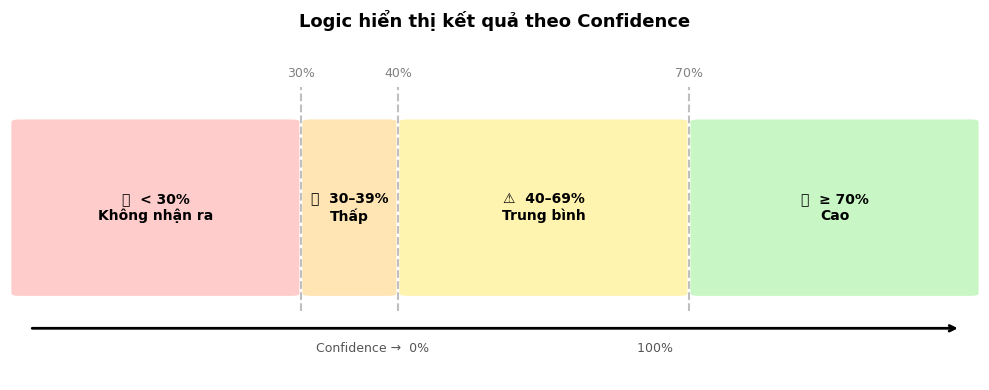

💾 Đã lưu: confidence_zones.png


In [7]:
UNKNOWN_THRESHOLD = 0.30   # < 30% → coi là unknown
HIGH_CONF         = 0.70   # >= 70% → màu xanh
MID_CONF          = 0.40   # >= 40% → màu vàng

def get_display_info(confidence):
    """Trả về (icon, color_name, message) theo ngưỡng confidence."""
    if confidence < UNKNOWN_THRESHOLD:
        return '❓', '#D85A30', 'Không nhận ra (ảnh không phải biển báo)'
    elif confidence >= HIGH_CONF:
        return '✅', '#1D9E75', 'Độ tự tin cao'
    elif confidence >= MID_CONF:
        return '⚠️', '#B8860B', 'Độ tự tin trung bình'
    else:
        return '❌', '#D85A30', 'Độ tự tin thấp'


# Visualize các mức confidence
fig, ax = plt.subplots(figsize=(10, 4))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Logic hiển thị kết quả theo Confidence', fontsize=13, fontweight='bold')

zones = [
    (0.00, 0.30, '#FFCCCC', '❓  < 30%\nKhông nhận ra'),
    (0.30, 0.40, '#FFE5B4', '❌  30–39%\nThấp'),
    (0.40, 0.70, '#FFF3B0', '⚠️  40–69%\nTrung bình'),
    (0.70, 1.00, '#C8F7C5', '✅  ≥ 70%\nCao'),
]

for x0, x1, color, label in zones:
    ax.add_patch(mpatches.FancyBboxPatch(
        (x0 + 0.01, 0.25), x1 - x0 - 0.02, 0.5,
        boxstyle='round,pad=0.01', facecolor=color, edgecolor='white', linewidth=2
    ))
    ax.text((x0 + x1) / 2, 0.5, label,
            ha='center', va='center', fontsize=10, fontweight='bold')

# Trục confidence
ax.annotate('', xy=(0.98, 0.15), xytext=(0.02, 0.15),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text(0.5, 0.08, 'Confidence →  0%                                                    100%',
        ha='center', fontsize=9, color='#555')

for thresh, label in [(0.30, '30%'), (0.40, '40%'), (0.70, '70%')]:
    ax.axvline(x=thresh, color='gray', linestyle='--', alpha=0.5, ymin=0.2, ymax=0.85)
    ax.text(thresh, 0.88, label, ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('confidence_zones.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Đã lưu: confidence_zones.png")

## 🔬 Bước 5 — Demo pipeline đầy đủ với ảnh tùy chọn

In [10]:
def demo_predict(image_path_or_pil, model, class_names):
    """
    Chạy toàn bộ pipeline predict và hiển thị kết quả như GUI.

    Tham số:
        image_path_or_pil : đường dẫn file ảnh hoặc PIL Image
        model             : Keras model
        class_names       : dict {int: str}
    """
    # Load ảnh
    if isinstance(image_path_or_pil, str):
        pil_img = Image.open(image_path_or_pil).convert("RGB")
        title_suffix = os.path.basename(image_path_or_pil)
    else:
        pil_img = image_path_or_pil.convert("RGB")
        title_suffix = "(PIL Image)"

    # Predict
    results = predict_top3(model, pil_img)
    top_cid, top_conf = results[0]
    top_name = class_names.get(top_cid, f'Class {top_cid}') if class_names else f'Class {top_cid}'
    icon, color, msg = get_display_info(top_conf)

    # Visualize
    fig = plt.figure(figsize=(13, 5))
    fig.suptitle(f'Demo GUI — {title_suffix}', fontsize=13, fontweight='bold')

    # Ảnh gốc
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.imshow(pil_img)
    ax1.set_title('Ảnh đầu vào', fontsize=10)
    ax1.axis('off')

    # Ảnh resize 30×30
    ax2 = fig.add_subplot(1, 3, 2)
    ax2.imshow(pil_img.resize((30, 30), Image.LANCZOS))
    ax2.set_title('Sau resize 30×30\n(đầu vào model)', fontsize=10)
    ax2.axis('off')

    # Kết quả
    ax3 = fig.add_subplot(1, 3, 3)
    ax3.axis('off')
    ax3.set_title('Kết quả Top 3', fontsize=10)

    # Top 1
    ax3.text(0.5, 0.92, f"{icon}  {top_name}",
             ha='center', va='center', fontsize=11, fontweight='bold',
             color=color, transform=ax3.transAxes, wrap=True)
    ax3.text(0.5, 0.78, f"{msg}\nConfidence: {top_conf*100:.1f}%",
             ha='center', va='center', fontsize=9,
             color=color, transform=ax3.transAxes)

    ax3.axhline(y=0.70, color='#DDD', xmin=0.05, xmax=0.95)

    # Top 2, 3
    medals = ['🥇', '🥈', '🥉']
    y_positions = [0.58, 0.42, 0.26]
    for rank, ((cid, conf), y_pos) in enumerate(zip(results, y_positions)):
        name = class_names.get(cid, f'Class {cid}') if class_names else f'Class {cid}'
        rank_icon, r_color, _ = get_display_info(conf)
        bar_width = conf

        ax3.add_patch(mpatches.FancyBboxPatch(
            (0.05, y_pos - 0.06), bar_width * 0.9, 0.10,
            boxstyle='round,pad=0.01',
            facecolor=r_color + '33', edgecolor=r_color,
            linewidth=1.5, transform=ax3.transAxes
        ))
        ax3.text(0.07, y_pos, f"{medals[rank]} [{cid:2d}] {name[:22]}",
                 ha='left', va='center', fontsize=8,
                 color='#222', transform=ax3.transAxes)
        ax3.text(0.93, y_pos, f"{conf*100:.1f}%",
                 ha='right', va='center', fontsize=8,
                 fontweight='bold', color=r_color, transform=ax3.transAxes)

    ax3.text(0.5, 0.06,
             f"Unknown threshold: {UNKNOWN_THRESHOLD*100:.0f}%  |  High conf: {HIGH_CONF*100:.0f}%",
             ha='center', fontsize=7.5, color='#999', transform=ax3.transAxes)

    plt.tight_layout()
    plt.savefig('gui_demo_result.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 Đã lưu: gui_demo_result.png")
    return results


print("✅ Hàm demo_predict đã định nghĩa")

✅ Hàm demo_predict đã định nghĩa


C:\Users\Lactv\AppData\Local\Temp\ipykernel_22972\2625207337.py:80: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()
C:\Users\Lactv\AppData\Local\Temp\ipykernel_22972\2625207337.py:80: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from current font.
  plt.tight_layout()
C:\Users\Lactv\AppData\Local\Temp\ipykernel_22972\2625207337.py:80: UserWarning: Glyph 129352 (\N{SECOND PLACE MEDAL}) missing from current font.
  plt.tight_layout()
C:\Users\Lactv\AppData\Local\Temp\ipykernel_22972\2625207337.py:80: UserWarning: Glyph 129353 (\N{THIRD PLACE MEDAL}) missing from current font.
  plt.tight_layout()
C:\Users\Lactv\AppData\Local\Temp\ipykernel_22972\2625207337.py:81: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.savefig('gui_demo_result.png', dpi=150, bbox_inches='tight')
C:\Users\Lactv\AppData\Local\Temp\ipykernel_22972\2625207337.py:81: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from current 

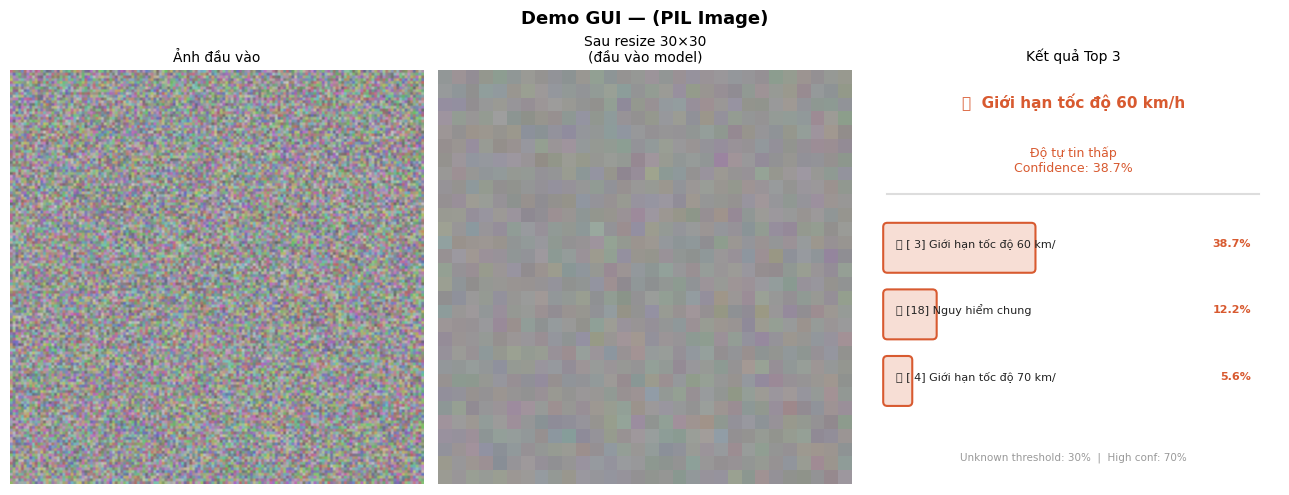

💾 Đã lưu: gui_demo_result.png


In [11]:
# Demo với ảnh ngẫu nhiên (thay bằng đường dẫn ảnh biển báo thực của bạn)
if model:
    test_pil = Image.fromarray(
        np.random.randint(100, 200, (150, 150, 3), dtype=np.uint8)
    )
    demo_results = demo_predict(test_pil, model, class_names)

# Thay bằng ảnh thực:
# demo_results = demo_predict("duong_dan_anh_bien_bao.jpg", model, class_names)

## 🏗️ Bước 6 — Sơ đồ kiến trúc GUI (Tkinter)

Giải thích cách các widget Tkinter được tổ chức trong cửa sổ.

C:\Users\Lactv\AppData\Local\Temp\ipykernel_25608\655401215.py:31: UserWarning: Glyph 128306 (\N{BLACK SQUARE BUTTON}) missing from current font.
  plt.tight_layout()
C:\Users\Lactv\AppData\Local\Temp\ipykernel_25608\655401215.py:31: UserWarning: Glyph 128678 (\N{VERTICAL TRAFFIC LIGHT}) missing from current font.
  plt.tight_layout()
C:\Users\Lactv\AppData\Local\Temp\ipykernel_25608\655401215.py:31: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from current font.
  plt.tight_layout()
C:\Users\Lactv\AppData\Local\Temp\ipykernel_25608\655401215.py:31: UserWarning: Glyph 128221 (\N{MEMO}) missing from current font.
  plt.tight_layout()
C:\Users\Lactv\AppData\Local\Temp\ipykernel_25608\655401215.py:31: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
C:\Users\Lactv\AppData\Local\Temp\ipykernel_25608\655401215.py:31: UserWarning: Glyph 127942 (\N{TROPHY}) missing from current font.
  plt.tight_layout()
C:\Users\Lactv\AppData\Local\Temp\

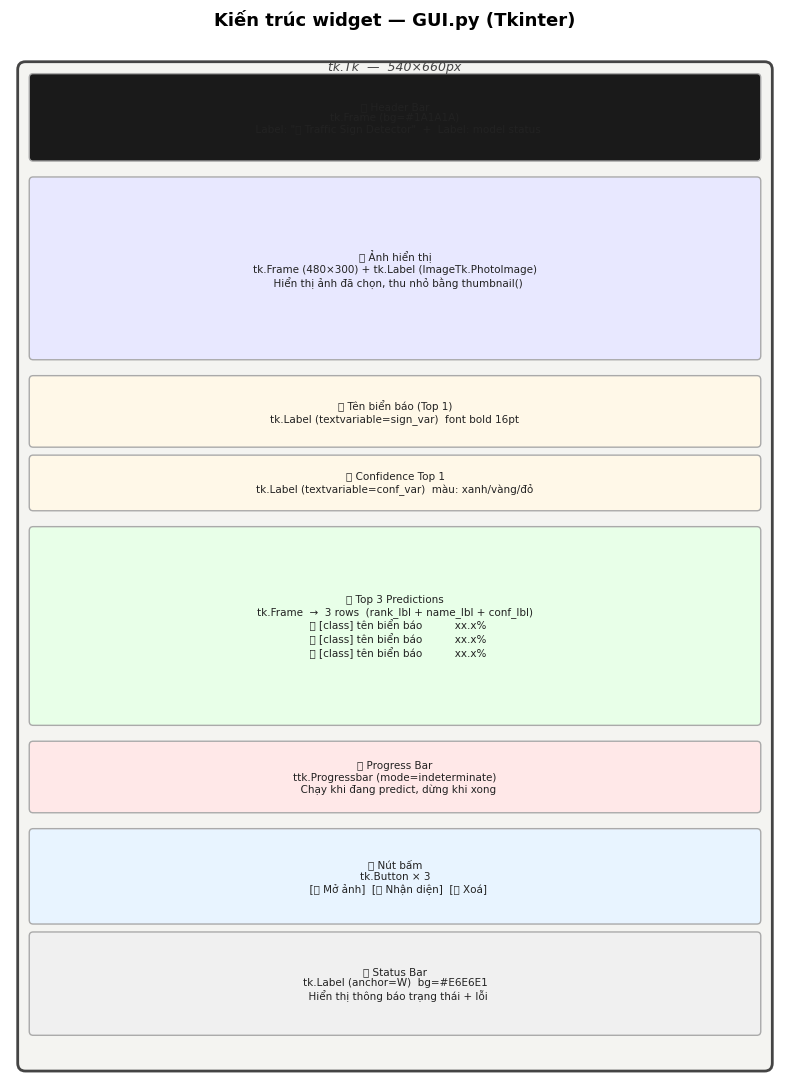

💾 Đã lưu: gui_architecture.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 11))
ax.set_xlim(0, 100)
ax.set_ylim(0, 130)
ax.axis('off')
ax.set_title('Kiến trúc widget — GUI.py (Tkinter)', fontsize=13, fontweight='bold', pad=15)

# Cửa sổ chính
ax.add_patch(mpatches.FancyBboxPatch((2, 2), 96, 125,
             boxstyle='round,pad=1', facecolor='#F4F4F1', edgecolor='#444', linewidth=2))
ax.text(50, 127, 'tk.Tk  —  540×660px', ha='center', fontsize=9, color='#444', style='italic')

widgets_layout = [
    # (x, y, w, h, color, text)
    (3,  116, 94, 10, '#1A1A1A', '🔲 Header Bar\ntk.Frame (bg=#1A1A1A)\n  Label: "🚦 Traffic Sign Detector"  +  Label: model status'),
    (3,  91,  94, 22, '#E8E8FF', '🖼️ Ảnh hiển thị\ntk.Frame (480×300) + tk.Label (ImageTk.PhotoImage)\n  Hiển thị ảnh đã chọn, thu nhỏ bằng thumbnail()'),
    (3,  80,  94,  8, '#FFF8E8', '📝 Tên biển báo (Top 1)\ntk.Label (textvariable=sign_var)  font bold 16pt'),
    (3,  72,  94,  6, '#FFF8E8', '📊 Confidence Top 1\ntk.Label (textvariable=conf_var)  màu: xanh/vàng/đỏ'),
    (3,  45,  94, 24, '#E8FFE8', '🏆 Top 3 Predictions\ntk.Frame  →  3 rows  (rank_lbl + name_lbl + conf_lbl)\n  🥇 [class] tên biển báo          xx.x%\n  🥈 [class] tên biển báo          xx.x%\n  🥉 [class] tên biển báo          xx.x%'),
    (3,  34,  94,  8, '#FFE8E8', '⏳ Progress Bar\nttk.Progressbar (mode=indeterminate)\n  Chạy khi đang predict, dừng khi xong'),
    (3,  20,  94, 11, '#E8F4FF', '🔘 Nút bấm\ntk.Button × 3\n  [📂 Mở ảnh]  [🔍 Nhận diện]  [🗑 Xoá]'),
    (3,   6,  94, 12, '#F0F0F0', '📟 Status Bar\ntk.Label (anchor=W)  bg=#E6E6E1\n  Hiển thị thông báo trạng thái + lỗi'),
]

for x, y, w, h, color, text in widgets_layout:
    ax.add_patch(mpatches.FancyBboxPatch((x, y), w, h,
                 boxstyle='round,pad=0.5', facecolor=color,
                 edgecolor='#AAA', linewidth=1))
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=7.5, color='#222')

plt.tight_layout()
plt.savefig('gui_architecture.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Đã lưu: gui_architecture.png")

## ⚡ Bước 7 — Luồng xử lý sự kiện GUI (Threading)

GUI dùng `threading.Thread` để predict không chặn UI thread.

C:\Users\Lactv\AppData\Local\Temp\ipykernel_22972\4239973837.py:81: UserWarning: Glyph 128194 (\N{OPEN FILE FOLDER}) missing from current font.
  plt.tight_layout()
C:\Users\Lactv\AppData\Local\Temp\ipykernel_22972\4239973837.py:81: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  plt.tight_layout()
C:\Users\Lactv\AppData\Local\Temp\ipykernel_22972\4239973837.py:82: UserWarning: Glyph 128194 (\N{OPEN FILE FOLDER}) missing from current font.
  plt.savefig('gui_event_flow.png', dpi=150, bbox_inches='tight')
C:\Users\Lactv\AppData\Local\Temp\ipykernel_22972\4239973837.py:82: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  plt.savefig('gui_event_flow.png', dpi=150, bbox_inches='tight')


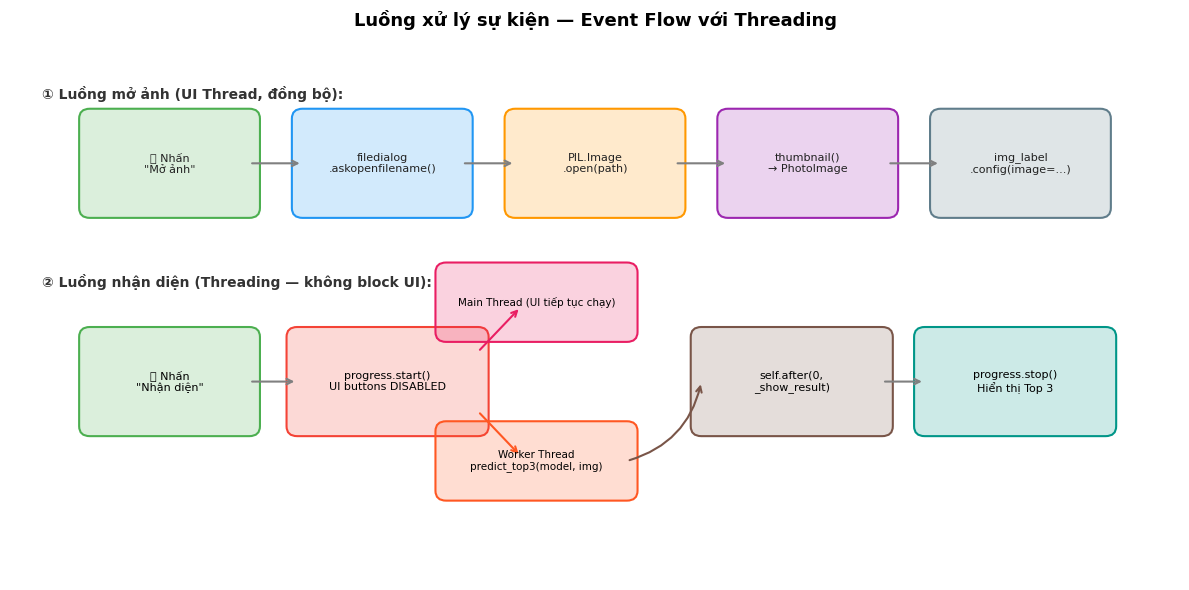

💾 Đã lưu: gui_event_flow.png


In [15]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')
ax.set_title('Luồng xử lý sự kiện — Event Flow với Threading', fontsize=13, fontweight='bold')

steps_open = [
    (1.5, 5.2, '#4CAF50', '📂 Nhấn\n"Mở ảnh"'),
    (3.5, 5.2, '#2196F3', 'filedialog\n.askopenfilename()'),
    (5.5, 5.2, '#FF9800', 'PIL.Image\n.open(path)'),
    (7.5, 5.2, '#9C27B0', 'thumbnail()\n→ PhotoImage'),
    (9.5, 5.2, '#607D8B', 'img_label\n.config(image=...)'),
]

steps_detect = [
    (1.5, 3.0, '#4CAF50', '🔍 Nhấn\n"Nhận diện"'),
    (3.0, 3.0, '#F44336', 'progress.start()\nbuttons DISABLED'),
    (4.8, 3.8, '#E91E63', 'UI Thread\n(không bị block)'),
    (4.8, 2.2, '#FF5722', 'Worker Thread\npredict_top3()'),
    (6.8, 3.0, '#795548', 'self.after(0,\n_show_result)'),
    (8.8, 3.0, '#009688', 'progress.stop()\nshow Top 3'),
]

# Vẽ flow "Mở ảnh"
ax.text(0.3, 5.85, '① Luồng mở ảnh (UI Thread, đồng bộ):',
        fontsize=10, fontweight='bold', color='#333')
for i, (x, y, color, text) in enumerate(steps_open):
    ax.add_patch(mpatches.FancyBboxPatch((x-0.75, y-0.45), 1.5, 0.9,
                 boxstyle='round,pad=0.1', facecolor=color+'33',
                 edgecolor=color, linewidth=1.5))
    ax.text(x, y, text, ha='center', va='center', fontsize=8, color='#222')
    if i < len(steps_open)-1:
        ax.annotate('', xy=(steps_open[i+1][0]-0.75, y),
                    xytext=(x+0.75, y),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

# Vẽ flow "Nhận diện"
ax.text(0.3, 3.95, '② Luồng nhận diện (Threading — không block UI):',
        fontsize=10, fontweight='bold', color='#333')
# Nút → disable + start progress
ax.add_patch(mpatches.FancyBboxPatch((0.75, 2.55), 1.5, 0.9,
             boxstyle='round,pad=0.1', facecolor='#4CAF5033', edgecolor='#4CAF50', linewidth=1.5))
ax.text(1.5, 3.0, '🔍 Nhấn\n"Nhận diện"', ha='center', va='center', fontsize=8)
ax.annotate('', xy=(2.7, 3.0), xytext=(2.25, 3.0),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

ax.add_patch(mpatches.FancyBboxPatch((2.7, 2.55), 1.7, 0.9,
             boxstyle='round,pad=0.1', facecolor='#F4433633', edgecolor='#F44336', linewidth=1.5))
ax.text(3.55, 3.0, 'progress.start()\nUI buttons DISABLED', ha='center', va='center', fontsize=8)

# Split → 2 threads
ax.annotate('', xy=(4.8, 3.75), xytext=(4.4, 3.3),
            arrowprops=dict(arrowstyle='->', color='#E91E63', lw=1.5))
ax.annotate('', xy=(4.8, 2.25), xytext=(4.4, 2.7),
            arrowprops=dict(arrowstyle='->', color='#FF5722', lw=1.5))

ax.add_patch(mpatches.FancyBboxPatch((4.1, 3.5), 1.7, 0.6,
             boxstyle='round,pad=0.1', facecolor='#E91E6333', edgecolor='#E91E63', linewidth=1.5))
ax.text(4.95, 3.8, 'Main Thread (UI tiếp tục chạy)', ha='center', va='center', fontsize=7.5)

ax.add_patch(mpatches.FancyBboxPatch((4.1, 1.9), 1.7, 0.6,
             boxstyle='round,pad=0.1', facecolor='#FF572233', edgecolor='#FF5722', linewidth=1.5))
ax.text(4.95, 2.2, 'Worker Thread\npredict_top3(model, img)', ha='center', va='center', fontsize=7.5)

# Worker → after() → show result
ax.annotate('', xy=(6.5, 3.0), xytext=(5.8, 2.2),
            arrowprops=dict(arrowstyle='->', color='#795548', lw=1.5,
                            connectionstyle='arc3,rad=0.3'))
ax.add_patch(mpatches.FancyBboxPatch((6.5, 2.55), 1.7, 0.9,
             boxstyle='round,pad=0.1', facecolor='#79554833', edgecolor='#795548', linewidth=1.5))
ax.text(7.35, 3.0, 'self.after(0,\n_show_result)', ha='center', va='center', fontsize=8)

ax.annotate('', xy=(8.6, 3.0), xytext=(8.2, 3.0),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

ax.add_patch(mpatches.FancyBboxPatch((8.6, 2.55), 1.7, 0.9,
             boxstyle='round,pad=0.1', facecolor='#00968833', edgecolor='#009688', linewidth=1.5))
ax.text(9.45, 3.0, 'progress.stop()\nHiển thị Top 3', ha='center', va='center', fontsize=8)

ax.set_xlim(0, 11)
ax.set_ylim(1, 6.5)

plt.tight_layout()
plt.savefig('gui_event_flow.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Đã lưu: gui_event_flow.png")

## 🚀 Bước 8 — Chạy GUI

> **Lưu ý:** Tkinter không chạy trong Jupyter Lab/Notebook trên một số môi trường server từ xa.
> Trong trường hợp đó, hãy chạy `GUI.py` trực tiếp bằng terminal.

In [ ]:
# Kiểm tra xem Tkinter có hoạt động trong môi trường này không
try:
    import tkinter as tk
    root = tk.Tk()
    root.withdraw()  # Ẩn cửa sổ test
    root.destroy()
    tkinter_ok = True
    print("✅ Tkinter hoạt động trong môi trường này.")
except Exception as e:
    tkinter_ok = False
    print(f"⚠️  Tkinter không khả dụng: {e}")
    print("   → Chạy GUI.py bằng terminal: python GUI.py")

✅ Tkinter hoạt động trong môi trường này.


In [ ]:
# Bỏ comment để chạy GUI (chỉ hoạt động khi có màn hình)

# if tkinter_ok:
#     import sys
#     sys.path.insert(0, os.getcwd())
#     # Chạy trực tiếp từ notebook:
#     exec(open('GUI.py').read())

print("💡 Để chạy GUI từ terminal:")
print("   python GUI.py")

💡 Để chạy GUI từ terminal:
   python GUI.py


## ✅ Tóm tắt toàn bộ dự án

| Notebook | File | Chức năng |
|---|---|---|
| `01_Train.ipynb` | `Train.py` | Load data, augment, train CNN, save model |
| `02_Camera.ipynb` | `Camera.py` | Nhận diện realtime qua webcam |
| `03_GUI.ipynb` | `GUI.py` | Giao diện Tkinter nhận diện từ file ảnh |

**Các file được tạo ra:**

```
Detect-Traffic-Signal/
├── traffic_classifier.h5   ← Model CNN (~19 MB)
├── labels.json             ← 43 nhãn biển báo tiếng Việt
├── Train.py / 01_Train.ipynb
├── Camera.py / 02_Camera.ipynb
├── GUI.py / 03_GUI.ipynb
├── Train/                  ← Dữ liệu huấn luyện
├── Test/                   ← Dữ liệu kiểm tra
└── Test.csv
```